In [ ]:
# -----------------------------
# Installation
# -----------------------------
!pip install -q open_clip_torch segment-anything opencv-python-headless
!pip install -q git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# ============================================================================
# COVID-ONLY CLIP-GUIDED SAM FOR MEDICAL ANOMALY DETECTION
# Zero-shot detection, CLIP→SAM integration, Confidence estimation
# ============================================================================



# -----------------------------
# Setup and Dataset Download
# -----------------------------
import os
import glob
import numpy as np
from PIL import Image
import cv2
from matplotlib import pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import transforms
import open_clip
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator
from scipy.ndimage import center_of_mass
import warnings
warnings.filterwarnings('ignore')

print("CUDA Available:", torch.cuda.is_available())

# Kaggle credentials
from google.colab import files
files.upload()

import os

# Create Kaggle config directory
os.makedirs("/root/.kaggle", exist_ok=True)

# Move kaggle.json
!mv kaggle.json /root/.kaggle/

# Set correct permissions (VERY IMPORTANT)
!chmod 600 /root/.kaggle/kaggle.json

print("kaggle.json configured correctly")


dataset_dir = "/content/datasets"
os.makedirs(dataset_dir, exist_ok=True)

# Download only COVID-related datasets (exclude Pneumonia)
kaggle_datasets = [
    "tawsifurrahman/covid19-radiography-database",
    "preetviradiya/covid19-radiography-dataset"
]

for ds in kaggle_datasets:
    print(f"\nDownloading {ds}...")
    !kaggle datasets download -d {ds} -p {dataset_dir} --unzip
    print(f"{ds} downloaded!")

# -----------------------------
# Device configuration
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nUsing device: {device}")


CUDA Available: True


Saving kaggle.json to kaggle.json
kaggle.json configured correctly

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
 98% 764M/778M [00:04<00:00, 134MB/s]
100% 778M/778M [00:04<00:00, 181MB/s]
tawsifurrahman/covid19-radiography-database downloaded!

Dataset URL: https://www.kaggle.com/datasets/preetviradiya/covid19-radiography-dataset
License(s): GPL-2.0
 98% 729M/747M [00:07<00:00, 50.4MB/s]
100% 747M/747M [00:07<00:00, 111MB/s] 
preetviradiya/covid19-radiography-dataset downloaded!

Using device: cuda


In [ ]:
from collections import Counter
import os, glob

dataset_root = "/content/datasets"

class_counts = Counter()

all_images = glob.glob(os.path.join(dataset_root, "**", "*.png"), recursive=True)

for img_path in all_images:
    parent_dir = os.path.basename(os.path.dirname(img_path)).lower()

    if parent_dir == "covid":
        class_counts["COVID"] += 1
    elif parent_dir == "normal":
        class_counts["Normal"] += 1

print("Class Distribution (COVID vs Normal):")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")


Class Distribution (COVID vs Normal):
COVID: 3616
Normal: 10192


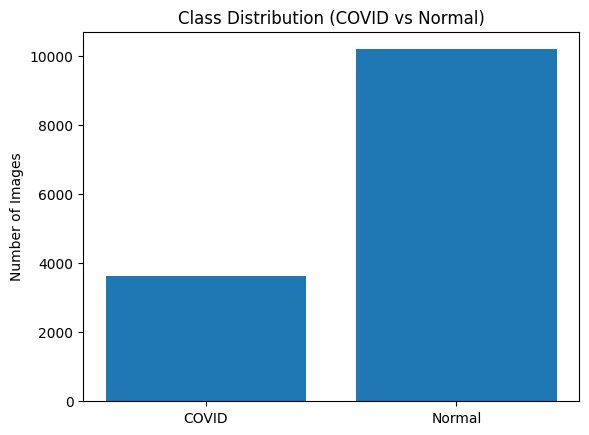

In [ ]:
import matplotlib.pyplot as plt

plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution (COVID vs Normal)")
plt.ylabel("Number of Images")
plt.show()


In [ ]:
from collections import Counter
import os, glob, random

dataset_root = "/content/datasets"

class_images = {
    "COVID": [],
    "Normal": []
}

all_images = glob.glob(os.path.join(dataset_root, "**", "*.png"), recursive=True)

for img_path in all_images:
    parent_dir = os.path.basename(os.path.dirname(img_path)).lower()

    if parent_dir == "covid":
        class_images["COVID"].append(img_path)
    elif parent_dir == "normal":
        class_images["Normal"].append(img_path)

print("Original Class Distribution:")
for k, v in class_images.items():
    print(f"{k}: {len(v)}")

Original Class Distribution:
COVID: 3616
Normal: 10192


In [ ]:
# -----------------------------
# Balanced Dataset (FIXED ORDER)
# -----------------------------
min_count = min(len(class_images["COVID"]), len(class_images["Normal"]))

balanced_images = (
    random.sample(class_images["COVID"], min_count) +
    random.sample(class_images["Normal"], min_count)
)

random.shuffle(balanced_images)

print(f"\nBalanced dataset per class: {min_count}")
print(f"Total balanced images    : {len(balanced_images)}")


Balanced dataset per class: 3616
Total balanced images    : 7232


In [ ]:
balanced_class_counts = Counter()

for p in balanced_images:
    parent_dir = os.path.basename(os.path.dirname(p)).lower()
    if parent_dir == "covid":
        balanced_class_counts["COVID"] += 1
    elif parent_dir == "normal":
        balanced_class_counts["Normal"] += 1

print("\nBalanced Class Distribution:")
for k, v in balanced_class_counts.items():
    print(f"{k}: {v}")


Balanced Class Distribution:
Normal: 3616
COVID: 3616


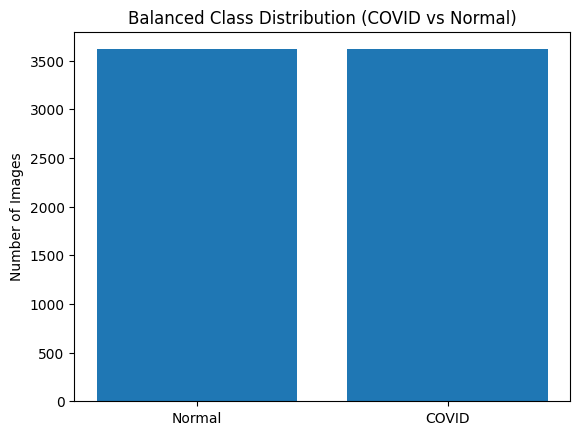

In [ ]:
import matplotlib.pyplot as plt

plt.bar(balanced_class_counts.keys(), balanced_class_counts.values())
plt.title("Balanced Class Distribution (COVID vs Normal)")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
# -----------------------------
# Download SAM checkpoint (ViT-H)
# -----------------------------
import os
import urllib.request

SAM_CHECKPOINT = "/content/sam_vit_h_4b8939.pth"

if not os.path.exists(SAM_CHECKPOINT):
    print("Downloading SAM checkpoint...")
    urllib.request.urlretrieve(
        "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth",
        SAM_CHECKPOINT
    )
    print("SAM checkpoint downloaded!")
else:
    print("SAM checkpoint already exists!")

SAM checkpoint downloaded!


In [ ]:
SAM_MODEL_TYPE = "vit_h"

sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_CHECKPOINT).to(device)
sam_predictor = SamPredictor(sam)

Using device: cuda
Original dataset distribution:
COVID: 3616
Normal: 10192

Balanced dataset per class: 3616
Total balanced images    : 7232

1. /content/datasets/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/COVID/COVID-464.png


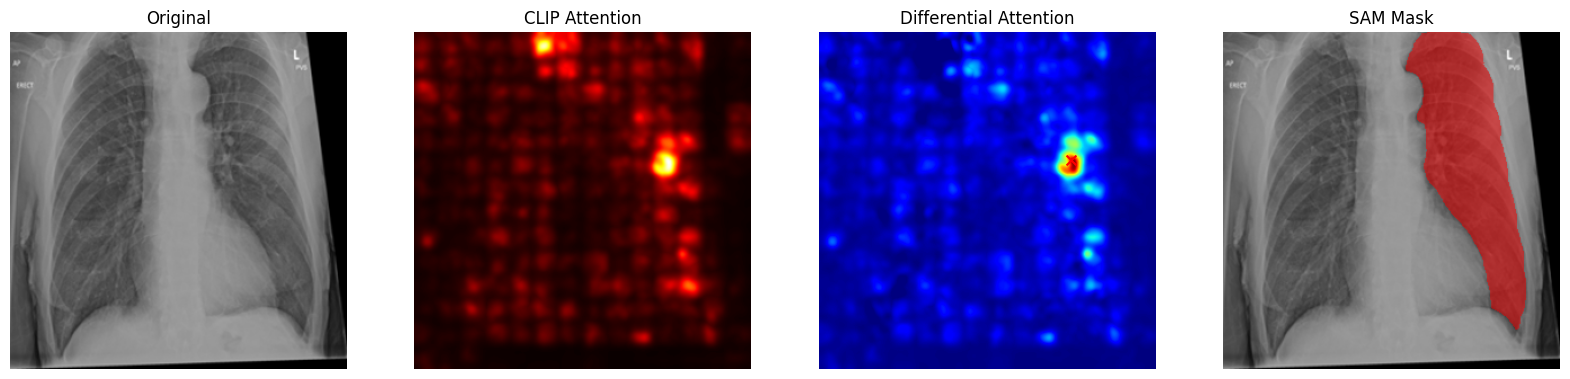

Confidence: 0.633 | Severity: Moderate

2. /content/datasets/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/COVID/COVID-2409.png


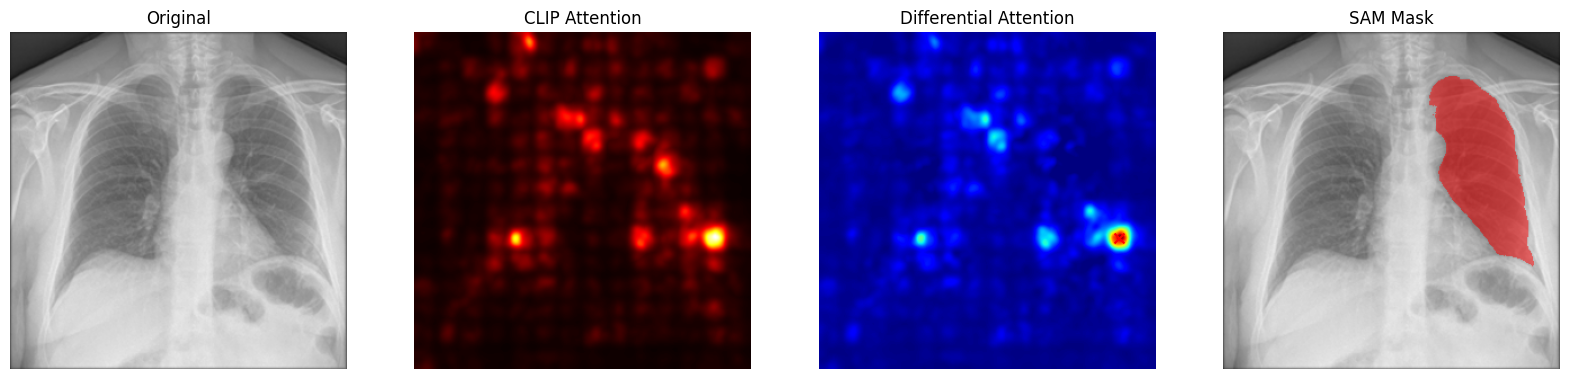

Confidence: 0.639 | Severity: Moderate

3. /content/datasets/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/Normal/Normal-4460.png


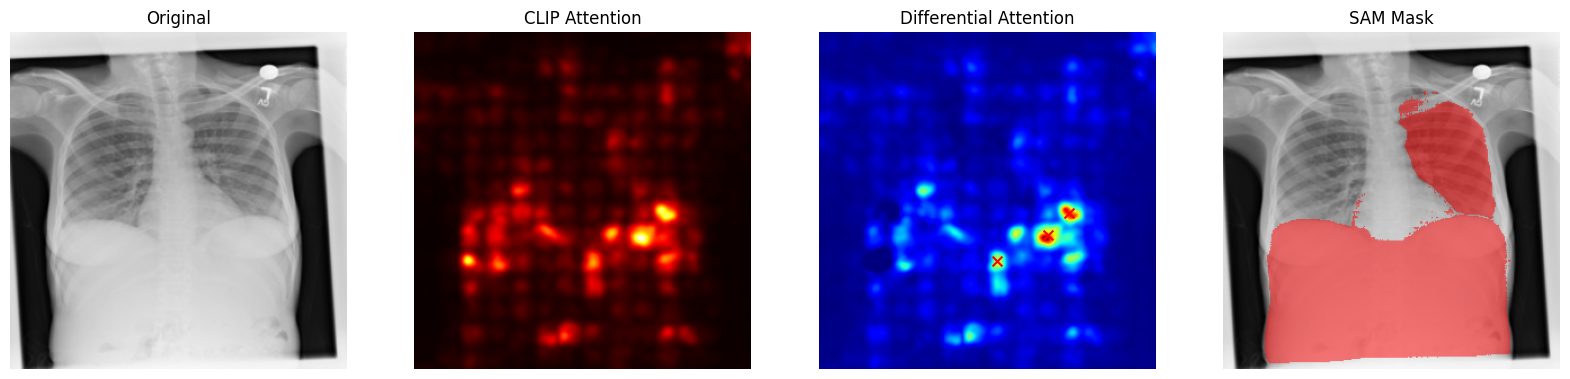

Confidence: 0.616 | Severity: Moderate

4. /content/datasets/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/Normal/Normal-3195.png


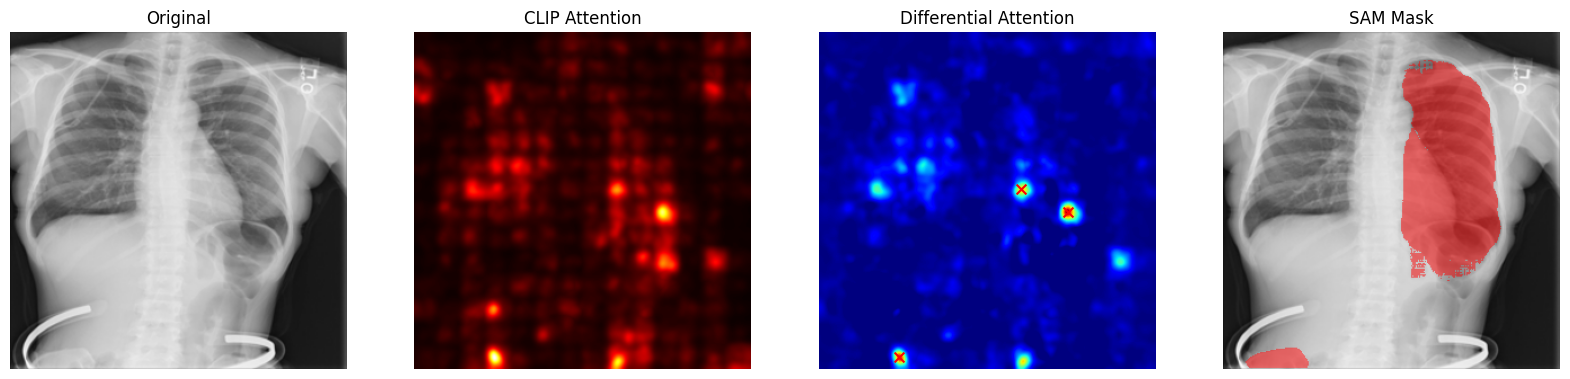

Confidence: 0.620 | Severity: Moderate

5. /content/datasets/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/COVID/COVID-2728.png


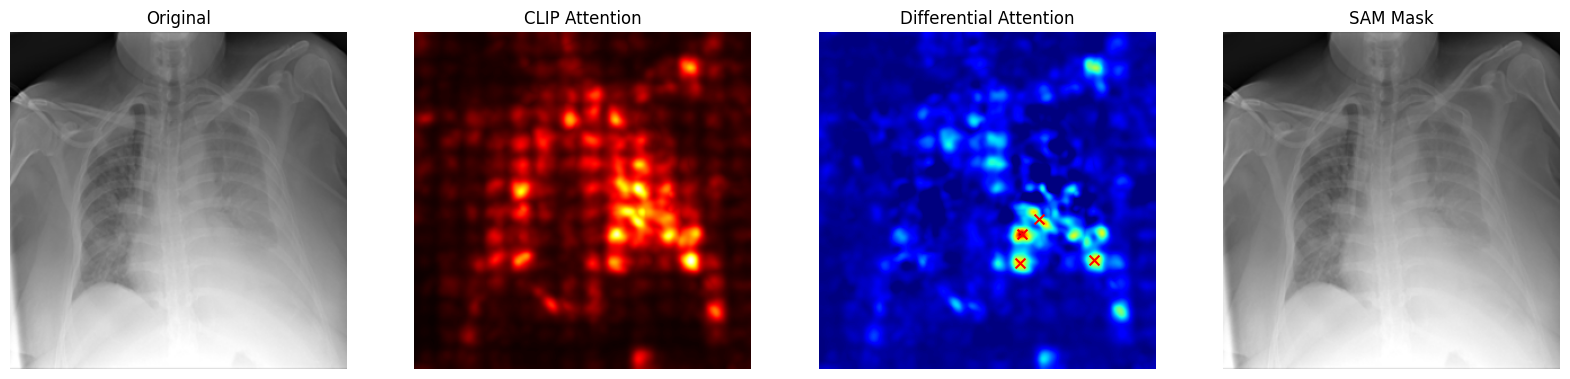

Confidence: 0.030 | Severity: Normal

6. /content/datasets/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/Normal/Normal-6137.png


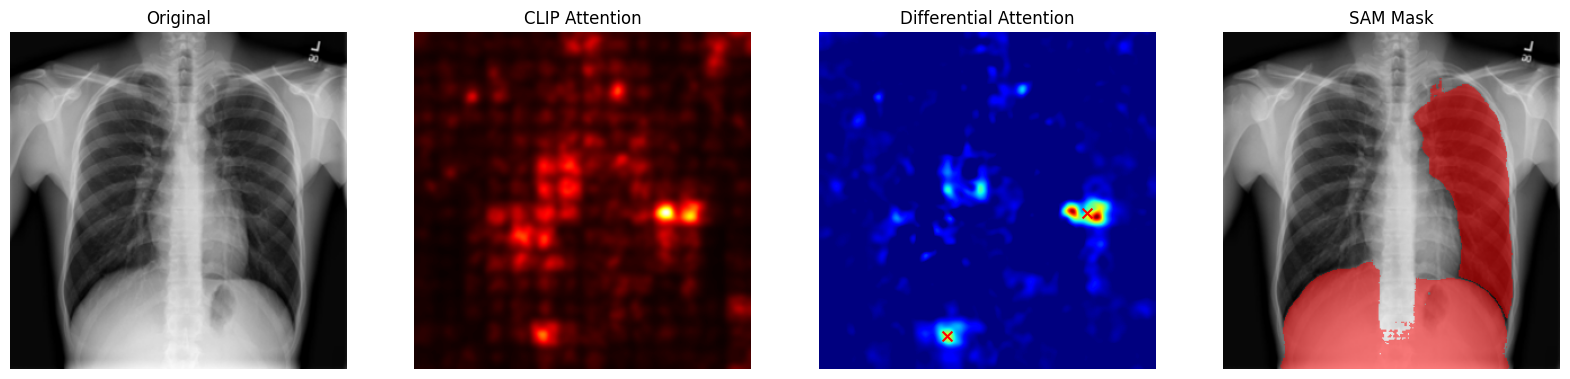

Confidence: 0.622 | Severity: Moderate

7. /content/datasets/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/Normal/Normal-271.png


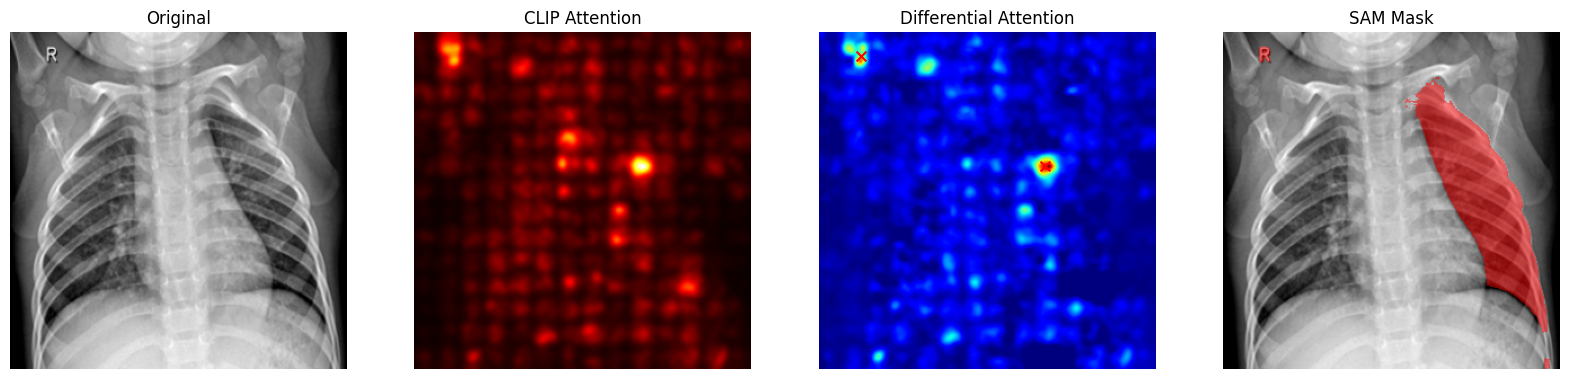

Confidence: 0.650 | Severity: Moderate

8. /content/datasets/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/COVID/COVID-2603.png


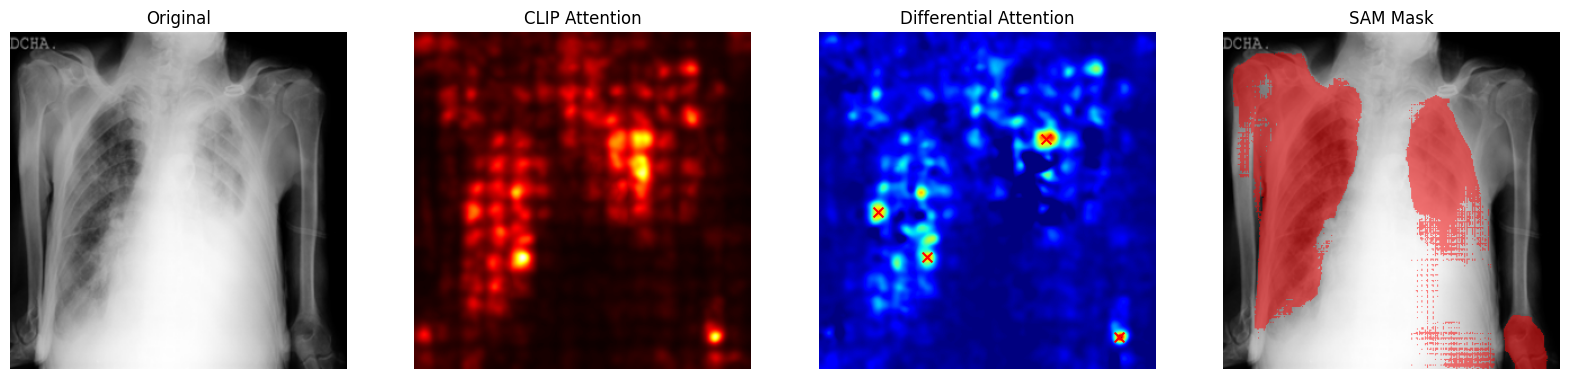

Confidence: 0.607 | Severity: Moderate

9. /content/datasets/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/Normal/Normal-6460.png


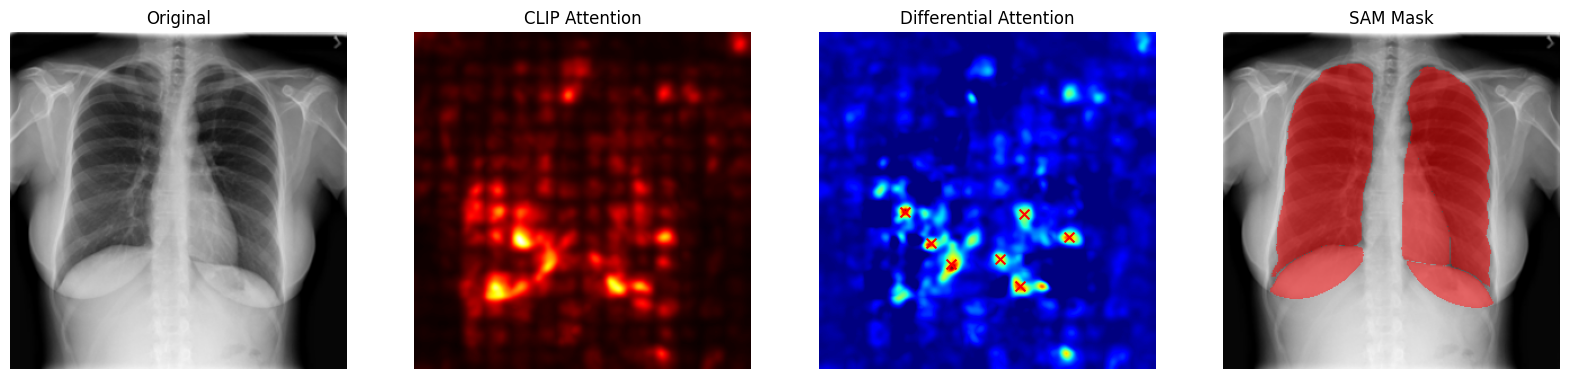

Confidence: 0.643 | Severity: Moderate

10. /content/datasets/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/Normal/Normal-1403.png


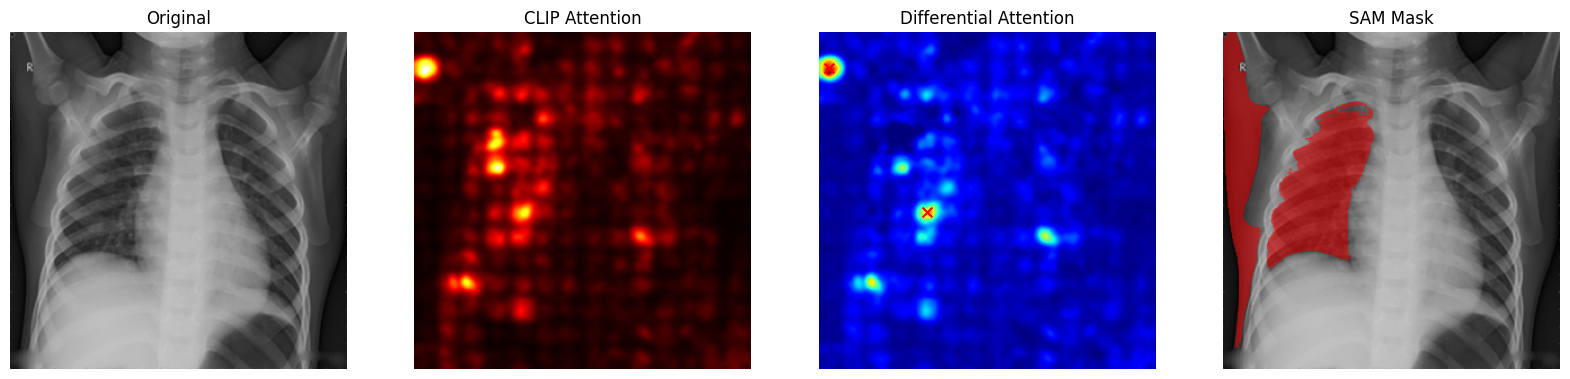

Confidence: 0.636 | Severity: Moderate


In [ ]:
# ============================================================
# CLIP + SAM Zero-Shot Anomaly Detection (COVID vs Normal)
# Evaluate 10 random images from balanced dataset
# ============================================================

import os, glob, random, cv2, torch, numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import open_clip
from segment_anything import sam_model_registry, SamPredictor
from scipy.ndimage import gaussian_filter

# -----------------------------
# Device
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# -----------------------------
# Prompts
# -----------------------------
ANOMALY_PROMPTS = {
    "COVID": [
        "COVID-19 infection, ground glass opacity, viral pneumonia",
        "patchy opacities, lung infection, inflammation",
        "lung consolidation, abnormal shadows, COVID infection"
    ],
    "Normal": [
        "healthy lungs, normal chest x-ray, no abnormalities"
    ]
}

# -----------------------------
# Dataset paths (FIXED LABELING)
# -----------------------------
dataset_root = "/content/datasets"
class_images = {"COVID": [], "Normal": []}

all_images = glob.glob(os.path.join(dataset_root, "**", "*.png"), recursive=True)

for img_path in all_images:
    parent_dir = os.path.basename(os.path.dirname(img_path)).lower()
    if parent_dir == "covid":
        class_images["COVID"].append(img_path)
    elif parent_dir == "normal":
        class_images["Normal"].append(img_path)

print("Original dataset distribution:")
for k, v in class_images.items():
    print(f"{k}: {len(v)}")

# -----------------------------
# Balanced dataset
# -----------------------------
min_count = min(len(class_images["COVID"]), len(class_images["Normal"]))

balanced_images = (
    random.sample(class_images["COVID"], min_count) +
    random.sample(class_images["Normal"], min_count)
)
random.shuffle(balanced_images)

print(f"\nBalanced dataset per class: {min_count}")
print(f"Total balanced images    : {len(balanced_images)}")

# -----------------------------
# CLIP + SAM Integration Class
# -----------------------------
class CLIPGuidedSAM:
    def __init__(self, clip_model, clip_preprocess, tokenizer, sam_predictor, device):
        self.clip_model = clip_model
        self.clip_preprocess = clip_preprocess
        self.tokenizer = tokenizer
        self.sam_predictor = sam_predictor
        self.device = device

    def get_clip_attention_map(self, image_path, text_prompt):
        image = Image.open(image_path).convert("RGB")
        original_size = image.size

        image_input = self.clip_preprocess(image).unsqueeze(0).to(self.device)
        text_input = self.tokenizer([text_prompt]).to(self.device)
        image_input.requires_grad_(True)

        image_features = self.clip_model.encode_image(image_input)
        text_features = self.clip_model.encode_text(text_input)

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        similarity = (image_features @ text_features.T).squeeze()
        similarity.backward()

        attention = image_input.grad[0].abs().mean(dim=0).cpu().numpy()
        attention = (attention - attention.min()) / (attention.max() - attention.min() + 1e-8)

        attention = cv2.resize(attention, original_size, interpolation=cv2.INTER_CUBIC)
        attention = gaussian_filter(attention, sigma=3)

        return attention, similarity.item()

    def detect_anomaly_regions(self, attention_map, threshold=0.45, min_region_size=80):
        binary_map = (attention_map > threshold).astype(np.uint8)
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            binary_map, connectivity=8
        )

        points = []
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] >= min_region_size:
                points.append([int(centroids[i][0]), int(centroids[i][1])])
        return points

    def segment_with_sam(self, image_path, points):
        if not points:
            return None, 0.0

        image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
        self.sam_predictor.set_image(image)

        h, w = image.shape[:2]
        combined_mask = np.zeros((h, w), dtype=bool)
        scores = []

        for pt in points:
            masks, s, _ = self.sam_predictor.predict(
                point_coords=np.array([pt]),
                point_labels=np.array([1]),
                multimask_output=True
            )

            for i in np.argsort(s)[::-1]:
                mask_area = np.sum(masks[i]) / (h * w)
                if 0.001 < mask_area < 0.35:
                    combined_mask |= masks[i]
                    scores.append(s[i])
                    break

        return combined_mask, (np.mean(scores) if scores else 0.0)

    def get_refined_confidence(self, image_path, mask, anomaly_prompts):
        if mask is None or np.sum(mask) == 0:
            return 0.0

        img = Image.open(image_path).convert("RGB")
        img_np = np.array(img)
        img_np[~mask] = 0

        masked_img = Image.fromarray(img_np)
        inputs = self.clip_preprocess(masked_img).unsqueeze(0).to(self.device)
        tokens = self.tokenizer(anomaly_prompts).to(self.device)

        with torch.no_grad():
            img_feat = self.clip_model.encode_image(inputs)
            txt_feat = self.clip_model.encode_text(tokens)

            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
            txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)

            sims = img_feat @ txt_feat.T
            max_sim = torch.max(sims).item()

        return (max_sim + 1) / 2

    def zero_shot_anomaly_detection(self, image_path, anomaly_prompts, normal_prompt):
        att_anom_list, sim_anom_list = [], []

        for prompt in anomaly_prompts:
            att, sim = self.get_clip_attention_map(image_path, prompt)
            att_anom_list.append(att)
            sim_anom_list.append(sim)

        att_anom = np.maximum.reduce(att_anom_list)
        att_norm, _ = self.get_clip_attention_map(image_path, normal_prompt)

        diff_attention = np.maximum(0, att_anom - att_norm)
        diff_attention /= diff_attention.max() + 1e-8

        points = self.detect_anomaly_regions(diff_attention)
        mask, sam_score = self.segment_with_sam(image_path, points)

        refined_conf = self.get_refined_confidence(image_path, mask, anomaly_prompts)
        global_sim = (np.mean(sim_anom_list) + 1) / 2

        final_confidence = 0.85 * refined_conf + 0.15 * global_sim

        # Suppress false positives if no mask
        if mask is None or np.sum(mask) == 0:
            final_confidence *= 0.3

        final_confidence = float(np.clip(final_confidence, 0, 1))

        return {
            "attention_map": diff_attention,
            "raw_attention_anomaly": att_anom,
            "mask": mask,
            "points": points,
            "confidence": final_confidence,
            "similarity_anomaly": np.mean(sim_anom_list),
            "sam_score": sam_score
        }

# -----------------------------
# Load Models
# -----------------------------
BIOMEDCLIP_MODEL = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
SAM_CHECKPOINT = "/content/sam_vit_h_4b8939.pth"
SAM_MODEL_TYPE = "vit_h"

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(BIOMEDCLIP_MODEL)
tokenizer = open_clip.get_tokenizer(BIOMEDCLIP_MODEL)
clip_model.to(device).eval()

sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_CHECKPOINT).to(device)
sam_predictor = SamPredictor(sam)

clip_sam_system = CLIPGuidedSAM(
    clip_model, clip_preprocess, tokenizer, sam_predictor, device
)

# -----------------------------
# Visualization
# -----------------------------
def severity_from_confidence(conf):
    if conf < 0.35: return "Normal"
    elif conf < 0.55: return "Mild"
    elif conf < 0.75: return "Moderate"
    else: return "Severe"

def visualize_results(image_path, results):
    image = np.array(Image.open(image_path).convert("RGB"))

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(results["raw_attention_anomaly"], cmap="hot")
    axes[1].set_title("CLIP Attention")
    axes[1].axis("off")

    axes[2].imshow(results["attention_map"], cmap="jet")
    if results["points"]:
        pts = np.array(results["points"])
        axes[2].scatter(pts[:, 0], pts[:, 1], c="red", s=50, marker="x")
    axes[2].set_title("Differential Attention")
    axes[2].axis("off")

    overlay = image.copy()
    if results["mask"] is not None:
        overlay[results["mask"]] = (
            overlay[results["mask"]] * 0.5 + np.array([255, 0, 0]) * 0.5
        )
    axes[3].imshow(overlay)
    axes[3].set_title("SAM Mask")
    axes[3].axis("off")

    plt.show()

    print(
        f"Confidence: {results['confidence']:.3f} | "
        f"Severity: {severity_from_confidence(results['confidence'])}"
    )

# -----------------------------
# Run on 10 random images
# -----------------------------
sample_images = random.sample(balanced_images, 10)

for idx, img_path in enumerate(sample_images, 1):
    results = clip_sam_system.zero_shot_anomaly_detection(
        img_path,
        ANOMALY_PROMPTS["COVID"],
        ANOMALY_PROMPTS["Normal"][0]
    )
    print(f"\n{idx}. {img_path}")
    visualize_results(img_path, results)


In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

# -----------------------------
# Threshold for predicting COVID
# -----------------------------
CONF_THRESHOLD = 0.5  # you can tune this

# -----------------------------
# Collect predictions and labels
# -----------------------------
y_true = []
y_pred = []
y_scores = []

for img_path in sample_images:
    results = clip_sam_system.zero_shot_anomaly_detection(img_path, ANOMALY_PROMPTS["COVID"], ANOMALY_PROMPTS["Normal"][0])
    # True label based on filename
    label = 1 if "COVID" in img_path.upper() else 0
    y_true.append(label)

    # Predicted label based on confidence threshold
    pred = 1 if results['confidence'] >= CONF_THRESHOLD else 0
    y_pred.append(pred)

    # Confidence score for ROC
    y_scores.append(results['confidence'])

# -----------------------------
# Metrics
# -----------------------------
acc = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# -----------------------------
# Print metrics
# -----------------------------
print("===== Zero-Shot CLIP+SAM Metrics =====")
print(f"Accuracy: {acc:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")
print(f"Average confidence: {np.mean(y_scores):.3f}")

===== Zero-Shot CLIP+SAM Metrics =====
Accuracy: 0.900
Recall: 0.900
F1-Score: 0.947
Average confidence: 0.570
